# Recommender Held-Out Evaluation Report

This notebook loads the final recommender evaluation for a single `run_id` and summarizes the **held-out test split**.

It is designed for the new recommender flow where:
- train/test are split by `dataset_index`
- final metrics come from the saved `evaluation_summary.json`
- missing recommender artifacts raise a clear error instead of silently falling back


In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)


In [2]:
# Edit these values to inspect another recommender run.
# RUN_ID = "federated-training-adult_income-20260426t223642651433+0000-logistic_regression-10clients-alpha0.3-seed42-e8df09baaba3"
# RUN_ID = "federated-training-adult_income-20260425t192946577949+0000-logistic_regression-10clients-alpha1.0-seed42-dba03a50b07b"
RUN_ID = "federated-training-adult_income-20260427t063710289874+0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2"
SELECTION_ID = "test__max-20__seed-42"
PERSONA = "lay"
RECOMMENDER_MODEL_KEY = "pairwise_logistic_fedavg"


In [3]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing pyproject.toml")


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def parse_run_id(run_id: str) -> dict[str, object]:
    info: dict[str, object] = {"run_id": run_id}
    match = re.search(
        r"federated-training-(?P<dataset>.+?)-(?P<timestamp>\d{8}t\d{6}\d+\+\d+)-(?P<model>.+?)-(?P<num_clients>\d+)clients-alpha(?P<alpha>[^-]+)-seed(?P<seed>\d+)",
        run_id,
    )
    if not match:
        return info
    info.update(match.groupdict())
    info["num_clients"] = int(info["num_clients"])
    info["seed"] = int(info["seed"])
    try:
        info["alpha"] = float(info["alpha"])
    except ValueError:
        pass
    return info


def resolve_train_dir(repo_root: Path, run_id: str, selection_id: str, persona: str, model_key: str) -> Path:
    return (
        repo_root
        / "federated"
        / "runs"
        / run_id
        / "recommender_training"
        / selection_id
        / persona
        / model_key
    )


def require_recommender_artifacts(train_dir: Path, run_id: str) -> dict[str, Path]:
    paths = {
        "evaluation_summary": train_dir / "evaluation_summary.json",
        "training_metadata": train_dir / "training_metadata.json",
        "model_artifact": train_dir / "model" / "global_recommender.npz",
    }
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        missing_text = ", ".join(missing)
        raise FileNotFoundError(
            f"Run {run_id!r} does not have completed recommender artifacts in {train_dir}. Missing: {missing_text}."
        )
    return paths


def format_value(value: object) -> str:
    if value is None:
        return "n/a"
    if isinstance(value, float):
        if math.isnan(value):
            return "n/a"
        return f"{value:.4f}"
    if isinstance(value, (list, tuple)):
        return ", ".join(str(item) for item in value)
    return str(value)


def make_metric_card(title: str, value: object, subtitle: str = "") -> str:
    subtitle_html = f"<div style='font-size:12px;color:#5f6368'>{subtitle}</div>" if subtitle else ""
    return (
        "<div style='padding:14px 16px;border:1px solid #d0d7de;border-radius:12px;"
        "background:#f8fafc;min-width:180px'>"
        f"<div style='font-size:12px;text-transform:uppercase;color:#5f6368;letter-spacing:0.04em'>{title}</div>"
        f"<div style='font-size:26px;font-weight:700;margin-top:4px'>{format_value(value)}</div>"
        f"{subtitle_html}"
        "</div>"
    )


def build_title_block(run_info: dict[str, object], training_metadata: dict, selection_id: str, persona: str) -> HTML:
    config = training_metadata.get("config", {})
    top_k = config.get("top_k", [])
    cards = [
        make_metric_card("Dataset", run_info.get("dataset")),
        make_metric_card("Model", run_info.get("model")),
        make_metric_card("Alpha", run_info.get("alpha")),
        make_metric_card("Clients", run_info.get("num_clients")),
        make_metric_card("K", top_k, "precision@K reported"),
        make_metric_card("Persona", persona),
        make_metric_card("Selection", selection_id),
        make_metric_card("Split", "held-out test", "final evaluation"),
    ]
    html = (
        "<div style='margin:8px 0 18px 0'>"
        "<div style='font-size:28px;font-weight:700;margin-bottom:6px'>Recommender Held-Out Test Results</div>"
        f"<div style='font-size:14px;color:#5f6368;margin-bottom:14px'><code>{run_info.get('run_id')}</code></div>"
        "<div style='display:flex;flex-wrap:wrap;gap:10px'>"
        + "".join(cards)
        + "</div></div>"
    )
    return HTML(html)


def safe_metric_columns(frame: pd.DataFrame) -> list[str]:
    columns = []
    for column in ["pearson", "precision_at_1", "precision_at_3", "precision_at_5"]:
        if column in frame.columns and frame[column].notna().any():
            columns.append(column)
    return columns


def summarize_metric(frame: pd.DataFrame, metric: str) -> dict[str, object]:
    valid = frame[["client_id", metric]].dropna()
    if valid.empty:
        return {
            "metric": metric,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "range": np.nan,
            "best_client": None,
            "worst_client": None,
        }
    best_idx = valid[metric].idxmax()
    worst_idx = valid[metric].idxmin()
    return {
        "metric": metric,
        "mean": valid[metric].mean(),
        "std": valid[metric].std(ddof=0),
        "min": valid[metric].min(),
        "max": valid[metric].max(),
        "range": valid[metric].max() - valid[metric].min(),
        "best_client": frame.loc[best_idx, "client_id"],
        "worst_client": frame.loc[worst_idx, "client_id"],
    }


def save_json(path: Path, payload: dict) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return path


def sanitize_segment(value: object) -> str:
    text = str(value).strip()
    cleaned = [char if (char.isalnum() or char in "._-") else "_" for char in text]
    normalized = "".join(cleaned).strip("._")
    return normalized or "value"


def aggregation_mode_label(training_metadata: dict) -> str:
    config = training_metadata.get("config", {})
    return "secure" if bool(config.get("secure_aggregation")) else "plain"


def resolve_notebook_output_dir(
    repo_root: Path,
    run_id: str,
    selection_id: str,
    persona: str,
    model_key: str,
    aggregation_mode: str,
) -> Path:
    return (
        repo_root
        / "notebooks"
        / "recommender_evaluation_outputs_secure"
        / sanitize_segment(run_id)
        / sanitize_segment(selection_id)
        / sanitize_segment(persona)
        / sanitize_segment(model_key)
        / sanitize_segment(aggregation_mode)
    )


def save_dataframe(frame: pd.DataFrame, output_dir: Path, stem: str, *, index: bool = False) -> dict[str, str]:
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / f"{stem}.csv"
    html_path = output_dir / f"{stem}.html"
    frame.to_csv(csv_path, index=index)
    frame.to_html(html_path, index=index)
    return {"csv": str(csv_path), "html": str(html_path)}


def save_figure(fig: plt.Figure, output_dir: Path, stem: str, *, dpi: int = 200) -> str:
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return str(path)


In [4]:
REPO_ROOT = find_repo_root()
TRAIN_DIR = resolve_train_dir(REPO_ROOT, RUN_ID, SELECTION_ID, PERSONA, RECOMMENDER_MODEL_KEY)
ARTIFACTS = require_recommender_artifacts(TRAIN_DIR, RUN_ID)

training_metadata = load_json(ARTIFACTS["training_metadata"])
evaluation_summary = load_json(ARTIFACTS["evaluation_summary"])
run_info = parse_run_id(RUN_ID)

if training_metadata.get("status") != "completed":
    raise ValueError(f"Recommender training for {RUN_ID!r} is not marked completed: {training_metadata.get('status')!r}")

if evaluation_summary.get("status") not in {None, "completed", "evaluated"}:
    raise ValueError(f"Unexpected evaluation status for {RUN_ID!r}: {evaluation_summary.get('status')!r}")

if training_metadata.get("eval_instance_count", 0) <= 0:
    raise ValueError(f"Run {RUN_ID!r} has no held-out evaluation instances recorded in training_metadata.json")

AGGREGATION_MODE = aggregation_mode_label(training_metadata)
OUTPUT_DIR = resolve_notebook_output_dir(
    REPO_ROOT,
    RUN_ID,
    SELECTION_ID,
    PERSONA,
    RECOMMENDER_MODEL_KEY,
    AGGREGATION_MODE,
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_EXPORT_MANIFEST = {
    "run_id": RUN_ID,
    "selection_id": SELECTION_ID,
    "persona": PERSONA,
    "model_key": RECOMMENDER_MODEL_KEY,
    "aggregation_mode": AGGREGATION_MODE,
    "train_dir": str(TRAIN_DIR),
    "output_dir": str(OUTPUT_DIR),
    "saved_tables": {},
    "saved_figures": {},
}
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

OUTPUT_DIR


PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/notebooks/recommender_evaluation_outputs_secure/federated-training-adult_income-20260427t063710289874_0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2/test__max-20__seed-42/lay/pairwise_logistic_fedavg/secure')

In [5]:
display(build_title_block(run_info, training_metadata, SELECTION_ID, PERSONA))

aggregate = dict(evaluation_summary.get("aggregate", {}))
aggregate.pop("dataset_index", None)

run_overview = pd.DataFrame(
    {
        "run_id": [RUN_ID],
        "selection_id": [SELECTION_ID],
        "persona": [PERSONA],
        "model_key": [RECOMMENDER_MODEL_KEY],
        "aggregation_mode": [AGGREGATION_MODE],
        "alpha": [run_info.get("alpha")],
        "num_clients": [run_info.get("num_clients")],
        "top_k": [training_metadata.get("config", {}).get("top_k", [])],
        "rounds_completed": [training_metadata.get("rounds_completed")],
        "simulation_backend": [training_metadata.get("simulation_backend_actual")],
        "train_instances": [training_metadata.get("instance_count")],
        "test_instances": [training_metadata.get("eval_instance_count")],
        "train_candidates": [training_metadata.get("candidate_count")],
        "test_candidates": [training_metadata.get("eval_candidate_count")],
        "train_pairs_raw": [training_metadata.get("raw_pair_count")],
        "test_pairs_raw": [training_metadata.get("eval_raw_pair_count")],
        "train_pairs_augmented": [training_metadata.get("pair_count")],
        "test_pairs_augmented": [training_metadata.get("eval_pair_count")],
        "aggregate_pearson": [aggregate.get("pearson")],
        "aggregate_precision_at_1": [aggregate.get("precision_at_1")],
        "aggregate_precision_at_3": [aggregate.get("precision_at_3")],
        "aggregate_precision_at_5": [aggregate.get("precision_at_5")],
    }
)

NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["run_overview"] = save_dataframe(run_overview, OUTPUT_DIR, "run_overview")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

run_overview


,run_id,selection_id,persona,model_key,aggregation_mode,alpha,num_clients,top_k,rounds_completed,simulation_backend,train_instances,test_instances,train_candidates,test_candidates,train_pairs_raw,test_pairs_raw,train_pairs_augmented,test_pairs_augmented,aggregate_pearson,aggregate_precision_at_1,aggregate_precision_at_3,aggregate_precision_at_5
0,federated-training-adult_income-20260427t063710289874+0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2,test__max-20__seed-42,lay,pairwise_logistic_fedavg,secure,0.3,15,"[1, 3, 5]",10,ray,240,60,11028,2766,255993,64338,511986,128676,0.833419,0.473064,0.601604,0.712994


In [6]:
client_eval_df = pd.DataFrame(evaluation_summary.get("clients", []))
if client_eval_df.empty:
    raise ValueError(f"Run {RUN_ID!r} has no per-client evaluation results in evaluation_summary.json")

client_train_df = pd.DataFrame(training_metadata.get("clients", []))
if not client_train_df.empty:
    client_train_df = client_train_df.rename(
        columns={
            "candidate_count": "train_candidate_count",
            "instance_count": "train_instance_count",
            "raw_pair_count": "train_pair_count_raw",
            "augmented_pair_count": "train_pair_count_augmented",
        }
    )
    keep_columns = [
        "client_id",
        "train_candidate_count",
        "train_instance_count",
        "train_pair_count_raw",
        "train_pair_count_augmented",
    ]
    client_df = client_eval_df.merge(client_train_df[keep_columns], on="client_id", how="left")
else:
    client_df = client_eval_df.copy()

metric_columns = safe_metric_columns(client_df)
client_df["average_metric_score"] = client_df[metric_columns].mean(axis=1, skipna=True)
client_df["test_pairs_per_instance"] = client_df["pair_count"] / client_df["instance_count"]
client_df["test_candidates_per_instance"] = client_df["candidate_count"] / client_df["instance_count"]

NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["client_metrics_full"] = save_dataframe(client_df, OUTPUT_DIR, "client_metrics_full")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

client_df[
    [
        "client_id",
        "instance_count",
        "candidate_count",
        "pair_count",
        *metric_columns,
        "average_metric_score",
        "train_instance_count",
        "train_candidate_count",
        "train_pair_count_raw",
    ]
].sort_values("average_metric_score", ascending=False)


,client_id,instance_count,candidate_count,pair_count,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,train_instance_count,train_candidate_count,train_pair_count_raw
12,client_012,4,158,3074,0.799453,1.000000,0.767187,0.657840,0.806120,16,593,10718
4,client_004,4,189,4502,0.898517,0.616615,0.608915,0.800000,0.731012,16,733,16675
11,client_011,4,143,2488,0.859520,0.493167,0.741827,0.802733,0.724312,16,572,9985
8,client_008,4,194,4713,0.964852,0.404838,0.721833,0.757989,0.712378,16,872,23615
1,client_001,4,217,5839,0.776480,0.781641,0.603985,0.662682,0.706197,16,793,19533
10,client_010,4,172,3621,0.882511,0.452914,0.674860,0.800000,0.702571,16,716,15856
13,client_013,4,204,5305,0.870409,0.643544,0.501288,0.666730,0.670493,16,720,15951
5,client_005,4,186,4270,0.772844,0.453396,0.635597,0.755691,0.654382,16,805,20226
9,client_009,4,208,5335,0.918089,0.238988,0.560200,0.847798,0.641269,16,833,21510
0,client_000,4,148,2669,0.794720,0.458973,0.495441,0.758262,0.626849,16,593,10753


In [7]:
aggregate_metric_frame = pd.DataFrame([summarize_metric(client_df, metric) for metric in metric_columns])
NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["aggregate_metric_summary"] = save_dataframe(aggregate_metric_frame, OUTPUT_DIR, "aggregate_metric_summary")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

aggregate_metric_frame


,metric,mean,std,min,max,range,best_client,worst_client
0,pearson,0.823592,0.101480,0.557540,0.964852,0.407312,client_008,client_003
1,precision_at_1,0.484004,0.203830,0.238988,1.000000,0.761012,client_012,client_009
2,precision_at_3,0.610288,0.087017,0.495441,0.767187,0.271746,client_012,client_000
3,precision_at_5,0.712851,0.105611,0.514682,0.859378,0.344696,client_007,client_006


In [8]:
top_clients = client_df.sort_values("average_metric_score", ascending=False).head(3)
bottom_clients = client_df.sort_values("average_metric_score", ascending=True).head(3)

NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["top_clients"] = save_dataframe(top_clients, OUTPUT_DIR, "top_clients")
NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["bottom_clients"] = save_dataframe(bottom_clients, OUTPUT_DIR, "bottom_clients")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

print("Top clients by average held-out score")
display(top_clients[["client_id", *metric_columns, "average_metric_score", "candidate_count", "pair_count"]].round(4))

print("Lowest clients by average held-out score")
display(bottom_clients[["client_id", *metric_columns, "average_metric_score", "candidate_count", "pair_count"]].round(4))


Top clients by average held-out score


,client_id,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,candidate_count,pair_count
12,client_012,0.7995,1.0000,0.7672,0.6578,0.8061,158,3074
4,client_004,0.8985,0.6166,0.6089,0.8000,0.7310,189,4502
11,client_011,0.8595,0.4932,0.7418,0.8027,0.7243,143,2488


Lowest clients by average held-out score


,client_id,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,candidate_count,pair_count
3,client_003,0.5575,0.2665,0.5824,0.7039,0.5276,151,2780
2,client_002,0.9427,0.2544,0.5029,0.5545,0.5636,222,6054
6,client_006,0.8644,0.4378,0.5036,0.5147,0.5801,174,3746


In [9]:
summary_columns = [
    "client_id",
    "instance_count",
    "candidate_count",
    "pair_count",
    *metric_columns,
    "average_metric_score",
    "test_candidates_per_instance",
    "test_pairs_per_instance",
    "train_instance_count",
    "train_candidate_count",
    "train_pair_count_raw",
]

client_report = client_df[summary_columns].sort_values("average_metric_score", ascending=False)
NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["client_report"] = save_dataframe(client_report, OUTPUT_DIR, "client_report")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

client_report.round(4)


,client_id,instance_count,candidate_count,pair_count,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,test_candidates_per_instance,test_pairs_per_instance,train_instance_count,train_candidate_count,train_pair_count_raw
12,client_012,4,158,3074,0.7995,1.0000,0.7672,0.6578,0.8061,39.50,768.50,16,593,10718
4,client_004,4,189,4502,0.8985,0.6166,0.6089,0.8000,0.7310,47.25,1125.50,16,733,16675
11,client_011,4,143,2488,0.8595,0.4932,0.7418,0.8027,0.7243,35.75,622.00,16,572,9985
8,client_008,4,194,4713,0.9649,0.4048,0.7218,0.7580,0.7124,48.50,1178.25,16,872,23615
1,client_001,4,217,5839,0.7765,0.7816,0.6040,0.6627,0.7062,54.25,1459.75,16,793,19533
10,client_010,4,172,3621,0.8825,0.4529,0.6749,0.8000,0.7026,43.00,905.25,16,716,15856
13,client_013,4,204,5305,0.8704,0.6435,0.5013,0.6667,0.6705,51.00,1326.25,16,720,15951
5,client_005,4,186,4270,0.7728,0.4534,0.6356,0.7557,0.6544,46.50,1067.50,16,805,20226
9,client_009,4,208,5335,0.9181,0.2390,0.5602,0.8478,0.6413,52.00,1333.75,16,833,21510
0,client_000,4,148,2669,0.7947,0.4590,0.4954,0.7583,0.6268,37.00,667.25,16,593,10753


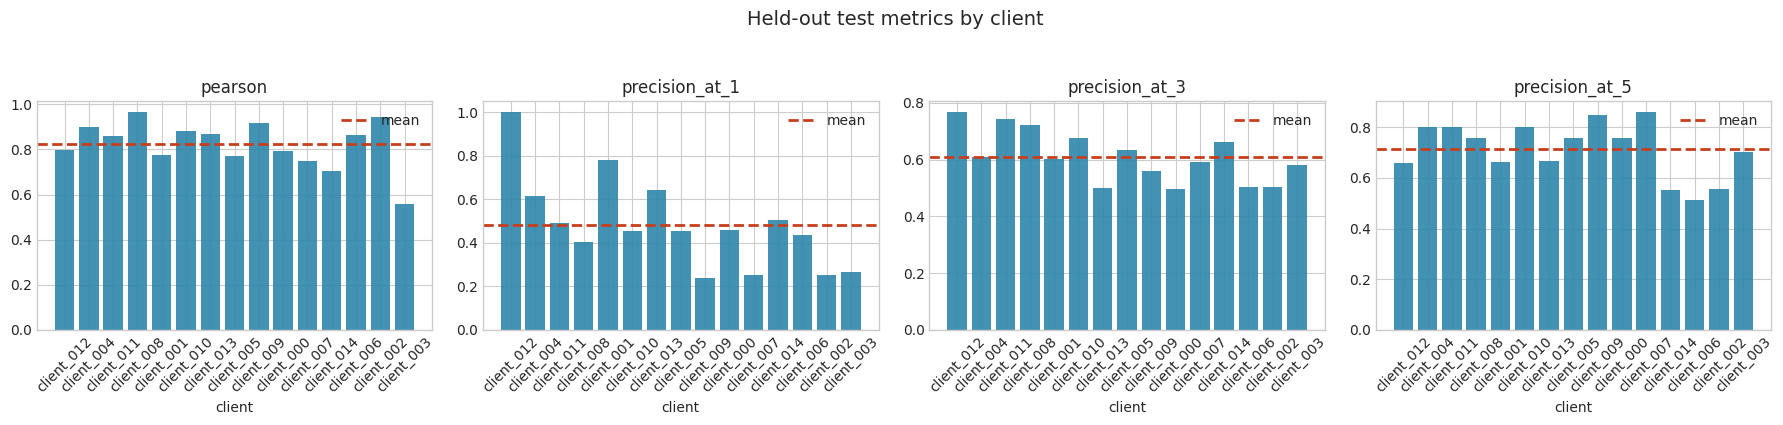

In [10]:
fig, axes = plt.subplots(1, len(metric_columns), figsize=(4.5 * len(metric_columns), 4), sharey=False)
if len(metric_columns) == 1:
    axes = [axes]

ordered = client_df.sort_values("average_metric_score", ascending=False)
for ax, metric in zip(axes, metric_columns):
    ax.bar(ordered["client_id"], ordered[metric], color="#2E86AB", alpha=0.9)
    ax.axhline(ordered[metric].mean(), color="#C73E1D", linestyle="--", linewidth=2, label="mean")
    ax.set_title(metric)
    ax.set_xlabel("client")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

plt.suptitle("Held-out test metrics by client", y=1.05, fontsize=14)
plt.tight_layout()
NOTEBOOK_EXPORT_MANIFEST["saved_figures"]["metrics_by_client"] = save_figure(fig, OUTPUT_DIR, "metrics_by_client")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)
plt.show()


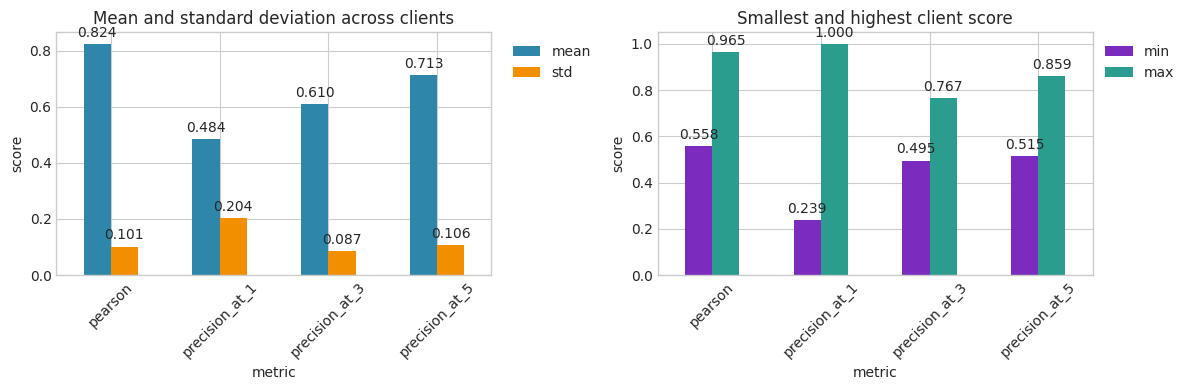

In [11]:
def annotate_bars(ax, fmt="{:.3f}", rotation=0, fontsize=10):
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            if pd.isna(height):
                labels.append("")
            else:
                labels.append(fmt.format(height))
        ax.bar_label(container, labels=labels, padding=3, rotation=rotation, fontsize=fontsize)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

aggregate_metric_frame.set_index("metric")[["mean", "std"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#2E86AB", "#F18F01"],
    title="Mean and standard deviation across clients",
)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("score")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
annotate_bars(axes[0])

aggregate_metric_frame.set_index("metric")[["min", "max"]].plot(
    kind="bar",
    ax=axes[1],
    color=["#7B2CBF", "#2A9D8F"],
    title="Smallest and highest client score",
)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("score")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
annotate_bars(axes[1])

plt.tight_layout()
NOTEBOOK_EXPORT_MANIFEST["saved_figures"]["mean_metrics"] = save_figure(fig, OUTPUT_DIR, "mean_metrics")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)
plt.show()

## Notes

- This notebook reads the **final post-training** recommender evaluation from `evaluation_summary.json`.
- The reported metrics are for the **held-out test split** only.
- If a `run_id` does not have completed recommender artifacts, the loading cell raises a clear error with the missing files.
